In [ ]:
#LAB3
#Kwantsimah Orleans Boham
#12912028

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cuda


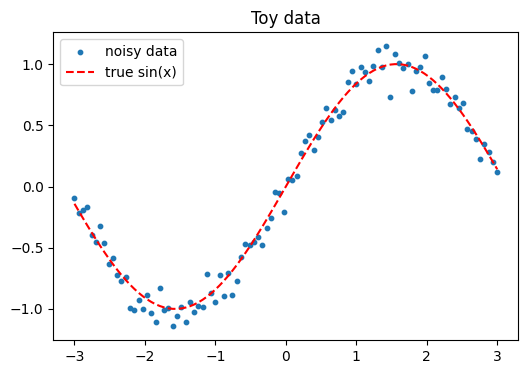

In [ ]:
#Section 1
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

plt.figure(figsize = (6, 4))
plt.scatter(x, y, s=10, label = "noisy data")
plt.plot(x, np.sin(x), 'r--', label = "true sin(x)")
plt.legend()
plt.title("Toy data")
plt.show()

In [ ]:
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

lr = 0.1
n_steps = 200
losses = []

for step in range(n_steps):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
    db    = np.mean(2 * (y_hat - y))

    w    -= lr * dw
    b    -= lr * db

print(len(losses), losses[:5], losses[-5:])

print(f"Final w = {w: .4f}, b= {b: .4f}, loss = {losses[-1]:.4f}")

200 [np.float64(0.9032945639381899), np.float64(0.302438028591318), np.float64(0.21186231534876973), np.float64(0.1981220033943185), np.float64(0.19598232605594412)] [np.float64(0.1954517971396205), np.float64(0.1954517971396205), np.float64(0.1954517971396205), np.float64(0.1954517971396205), np.float64(0.1954517971396205)]
Final w =  0.3390, b= -0.0104, loss = 0.1955


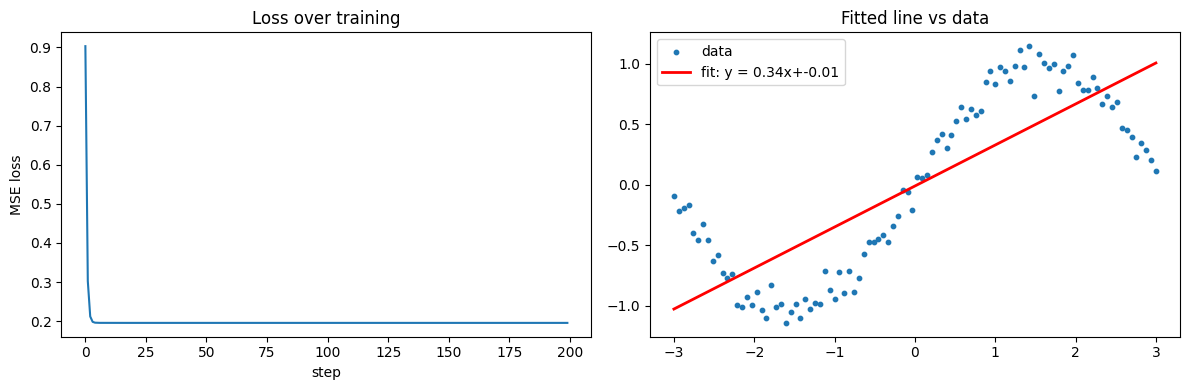

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


#loss curve
axes[0].plot(losses)
axes[0].set_xlabel("step")
axes[0].set_ylabel("MSE loss")
axes[0].set_title("Loss over training")

axes[1].scatter(x, y, s=10, label = "data")
axes[1].plot(x, w * x + b, 'r-', linewidth = 2, label = f"fit: y = {w:.2f}x+{b:.2f}")
axes[1].legend()
axes[1].set_title("Fitted line vs data")

plt.tight_layout()
plt.show()

In [ ]:
#SECTION 1.2
x2 = x.reshape(-1, 1)
y2 = y.reshape(-1, 1)

np.random.seed(0)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

def forward(x2, W1, b1, W2, b2):
    z1 = x2 @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    return z1, h, y_hat

lr = 0.05
n_steps = 3000
losses = []

for step in range(n_steps):
  z1 = x2 @ W1 + b1
  h = np.tanh(z1)
  y_hat = h @ W2 + b2
  loss = np.mean((y_hat - y2) ** 2)
  losses.append(loss)

  d_yhat = 2 * (y_hat - y2) / len(y2)
  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis = 0)
  dh = d_yhat @ W2.T
  dz1 = dh * (1 - np.tanh(z1) ** 2)
  dW1 = x2.T @ dz1
  db1 = dz1.sum(axis = 0)

#update
  W1 -= lr * dW1
  b1 -= lr * db1
  W2 -= lr * dW2
  b2 -= lr * db2

print(f"Final loss:  {losses[-1]:.5f}")

Final loss:  0.01299


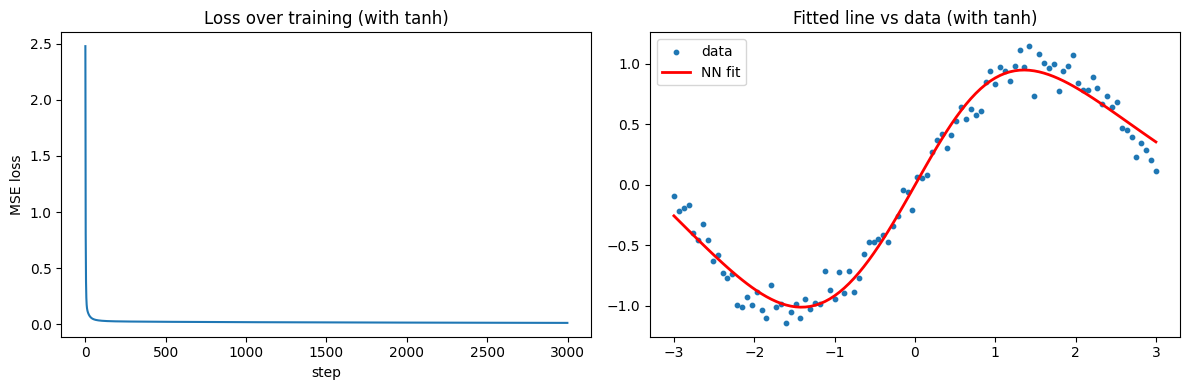

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#loss
axes[0].plot(losses)
axes[0].set_xlabel("step")
axes[0].set_ylabel("MSE loss")
axes[0].set_title("Loss over training (with tanh)")

#recompute final prediction for plotting
_, _, y_hat_final = forward(x2, W1, b1, W2, b2)

axes[1].scatter(x, y, s=10, label = "data")
axes[1].plot(x, y_hat_final, 'r-', linewidth=2, label = "NN fit")
axes[1].legend()
axes[1].set_title("Fitted line vs data (with tanh)")

plt.tight_layout()
plt.show()

In [ ]:
##plot after removing tanh
np.random.seed(0)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

lr = 0.05
n_steps = 3000
losses_no_tanh = []

for step in range(n_steps):
  z1 = x2 @ W1 + b1
  h = z1
  y_hat = h @ W2 + b2
  loss = np.mean((y_hat - y2) ** 2)
  losses_no_tanh.append(loss)

  d_yhat = 2 * (y_hat - y2) / len(y2)
  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis = 0)
  dh = d_yhat @ W2.T
  dz1 = dh
  dW1 = x2.T @ dz1
  db1 = dz1.sum(axis = 0)

  W1 -= lr * dW1
  b1 -= lr * db1
  W2 -= lr * dW2
  b2 -= lr * db2

print(f"Final loss:  {losses_no_tanh[-1]:.5f}")


Final loss:  0.19545


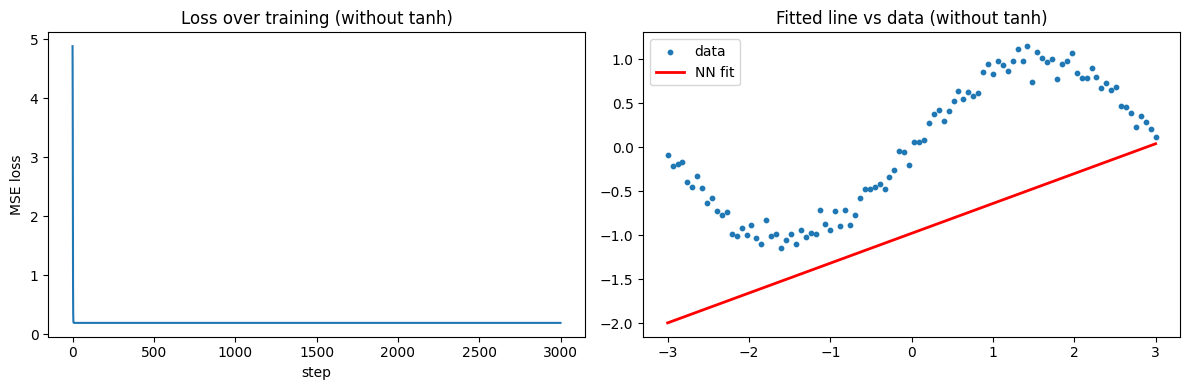

In [ ]:
fig, axes  = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(losses_no_tanh)
axes[0].set_xlabel("step")
axes[0].set_ylabel("MSE loss")
axes[0].set_title("Loss over training (without tanh)")

z1 = x2 @ W1 + b1
h = z1
y_hat_final = h @ W2 + b


axes[1].scatter(x, y, s=10, label = "data")
axes[1].plot(x, y_hat_final, 'r-', linewidth=2, label = "NN fit")
axes[1].legend()
axes[1].set_title("Fitted line vs data (without tanh)")

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_724/3906949597.py:14: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y2) ** 2)
/tmp/ipykernel_724/3906949597.py:20: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_724/3906949597.py:21: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


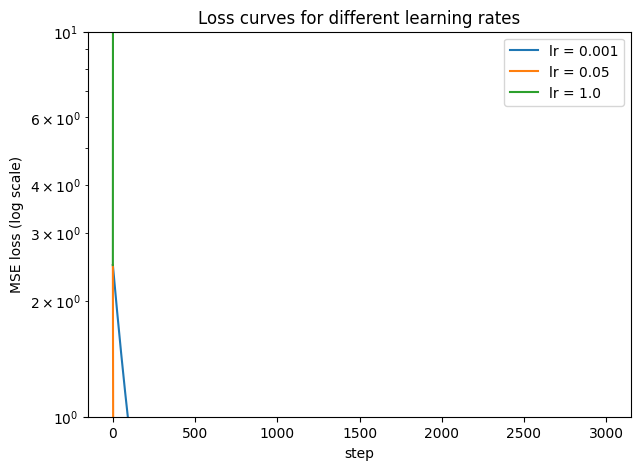

0.041110994545246554 0.012990299804299367 nan


In [ ]:
#SECTION 1.3
def train_toy(lr, steps = 3000):
  np.random.seed(0)
  W1 = np.random.randn(1, 8) * 0.5
  b1 = np.random.randn(8) * 0.5
  W2 = np.random.randn(8, 1) * 0.5
  b2 = np.random.randn(1) * 0.5

  losses = []
  for step in range(steps):
    z1 = x2 @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y2) ** 2)
    losses.append(loss)

    d_yhat = 2 * (y_hat - y2) / len(y2)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis = 0)
    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x2.T @ dz1
    db1 = dz1.sum(axis = 0)

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

  return losses

losses_001  = train_toy(lr = 0.001)
losses_005  = train_toy(lr = 0.05)
losses_01   = train_toy(lr = 1.0)

plt.figure(figsize = (7, 5))
plt.plot(losses_001, label = "lr = 0.001")
plt.plot(losses_005, label = "lr = 0.05")
plt.plot(losses_01, label = "lr = 1.0")

plt.yscale("log")
plt.xlabel("step")
plt.ylabel("MSE loss (log scale)")
plt.title("Loss curves for different learning rates")
plt.legend()
plt.show()

print(losses_001[-1], losses_005[-1], losses_01[-1])